In [1]:
import multiprocessing as mp
from functools import partial
from dataclasses import dataclass

import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

import DMdecay as dmd
import JWSTutils as jwst
from gnz11_split import partition_gnz11

In [2]:
run_dir = "gnz11_split"
prev_config_path = F"{run_dir}/gnz11_split.toml"

In [3]:
prev_configs = dmd.prep.parse_configs(prev_config_path)
run_name = prev_configs["run"]["name"]

data = jwst.process_datafiles(prev_configs["run"]["paths"], 
                                prev_configs["system"]["res_path"])
data = partition_gnz11(data, prev_configs["run"]["lambda_min"],
                        prev_configs["run"]["lambda_split"])
for spec in data:
    dmd.prep.doppler_correction(spec, prev_configs["halo"])
    dmd.prep.add_Dfactor(spec, prev_configs["halo"])
    spec["sigma_v"] = prev_configs["halo"]["sigma_v"]

base_specset = dmd.prep.SpecSetfromList(data)

parsing gnz11_split/gnz11_split.toml
processing 2 datafiles...


In [4]:
for k, v in prev_configs.items():
    print(k)
    print()
    for kk, vv in v.items():
        print(f"  {kk}: {vv}")

run

  name: gnz11_split
  filenames: ['jw04426-o001_t001_nirspec_g235m-f170lp/jw04426-o001_t001_nirspec_g235m-f170lp_x1d.fits', 'jw04426-o001_t001_nirspec_g140m-f100lp/jw04426-o001_t001_nirspec_g140m-f100lp_x1d.fits']
  lambda_split: 1.65978
  lambda_min: 0.99
  rawlimits_filename: line-rawlimits.out
  bestfits_filename: line-bestfits.out
  pc_filename: line-pc.out
  lineoutput_filename: line-output.json
  fluxlimits_filename: flux-limits.out
  paths: ['data/mastDownload/JWST/jw04426-o001_t001_nirspec_g235m-f170lp/jw04426-o001_t001_nirspec_g235m-f170lp_x1d.fits', 'data/mastDownload/JWST/jw04426-o001_t001_nirspec_g140m-f100lp/jw04426-o001_t001_nirspec_g140m-f100lp_x1d.fits']
analysis

  width_factor: 150.0
  padding: 1e-08
  num_knots: 5
  chisq_step: 4.0
  limit_guess: [1e-05, 0.001]
  max_clip_iters: 100
  clipping_factor: 3.0
  Ntrials: 1000
  Nbins: 15
  power_threshold: 0.1587
  Nthreads: 7
  inflate: 1
  checkpoint: 30
halo

  rho_s: 0.18
  r_s: 24.0
  sigma_v_kms: 160.0
  r_sun:

In [5]:
old_rawlimits = np.loadtxt(
    F"{run_name}/{prev_configs['run']['rawlimits_filename']}")
valid = np.isfinite(old_rawlimits[:, 1])
mass_to_test = old_rawlimits[valid, :][:, 0]
lam_to_test = dmd.conversions.mass_to_wavelength(mass_to_test)
Nlams = lam_to_test.shape[0]
exisitng_limit_invsec = old_rawlimits[valid, :][:, 1]
decayrate_to_test = \
    dmd.conversions.invsec_to_fluxscale(exisitng_limit_invsec)

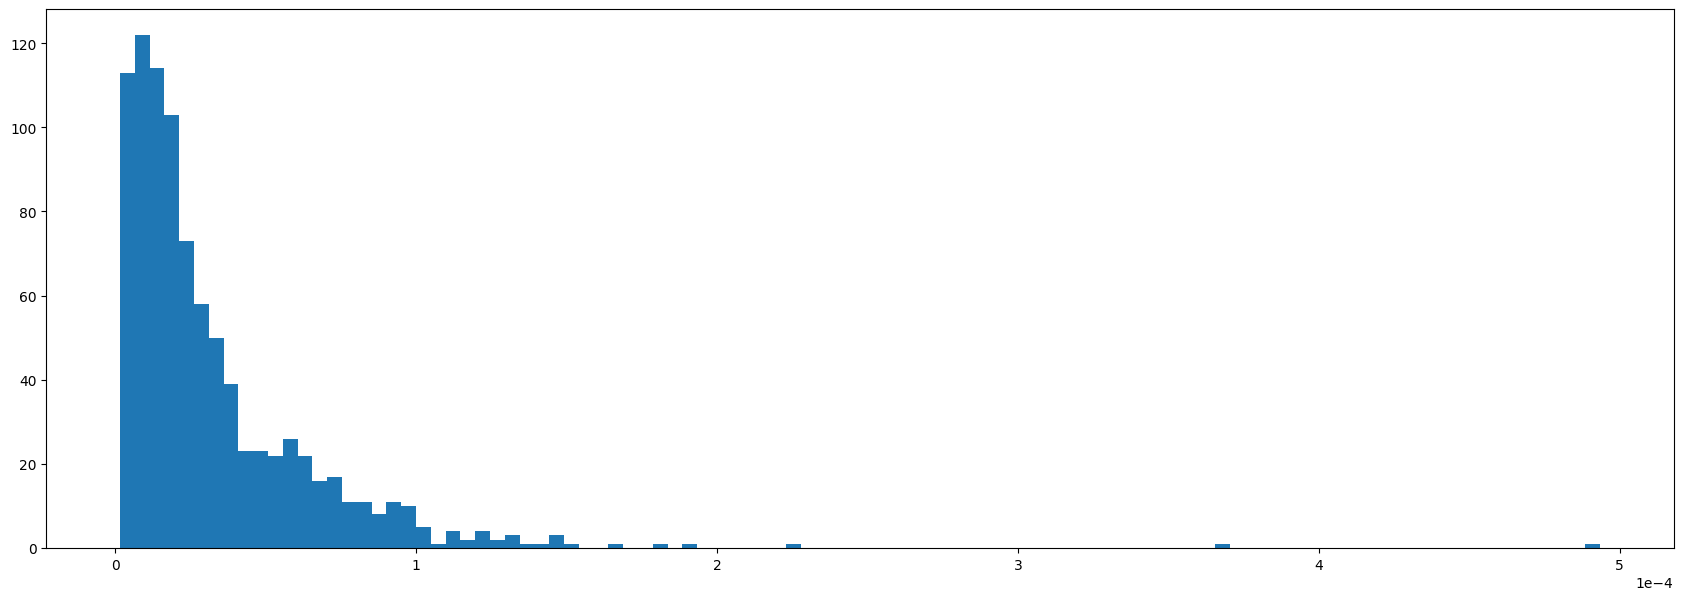

In [6]:
fig, ax = plt.subplots(figsize=(21, 7))
ax.hist(decayrate_to_test, bins=100)
np.quantile(decayrate_to_test, [0.1, 0.5, 0.9])
ax.axes.ticklabel_format(axis="x", style="sci", scilimits=(0, 0))

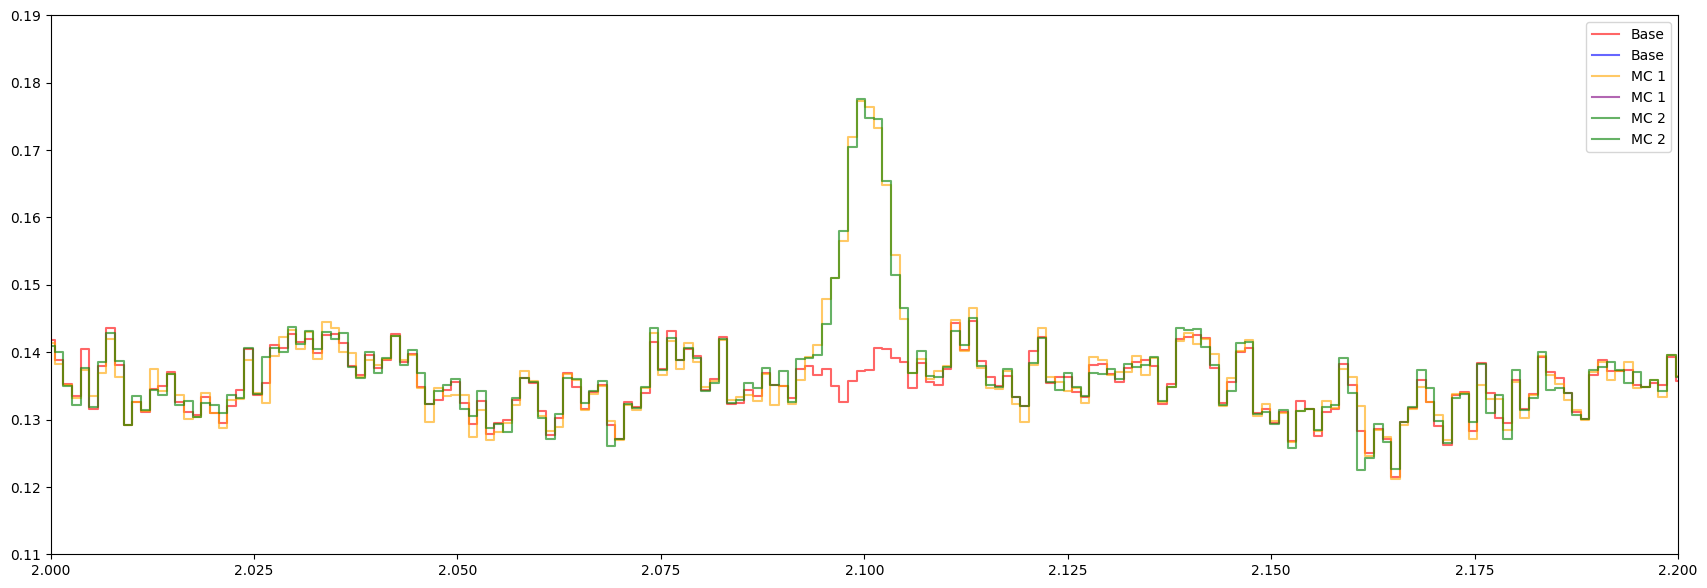

In [7]:
decayrate = 2e-4
lam0 = 2.1

new_specset = base_specset.add_DM_line(decayrate, lam0).resample_flux()

fig, ax = plt.subplots(figsize=(21, 7))
base_specset.plot(ax=ax, error_band=0, 
             distinct_plot_args=[{"color": "red"},
                                 {"color": "blue"}],
             alpha=0.6, label="Base")
new_specset.plot(ax=ax, error_band=0,
             distinct_plot_args=[{"color": "orange"},
                                 {"color": "purple"},],
             alpha=0.6, label="MC 1")

new_specset = base_specset.add_DM_line(decayrate, lam0).resample_flux()
new_specset.plot(ax=ax, error_band=0, color='green',
                alpha=0.6, label="MC 2")


ax.set_xlim(lam0 - 0.1, lam0 + 0.1)
ax.set_ylim(0.11, 0.19)
ax.legend()

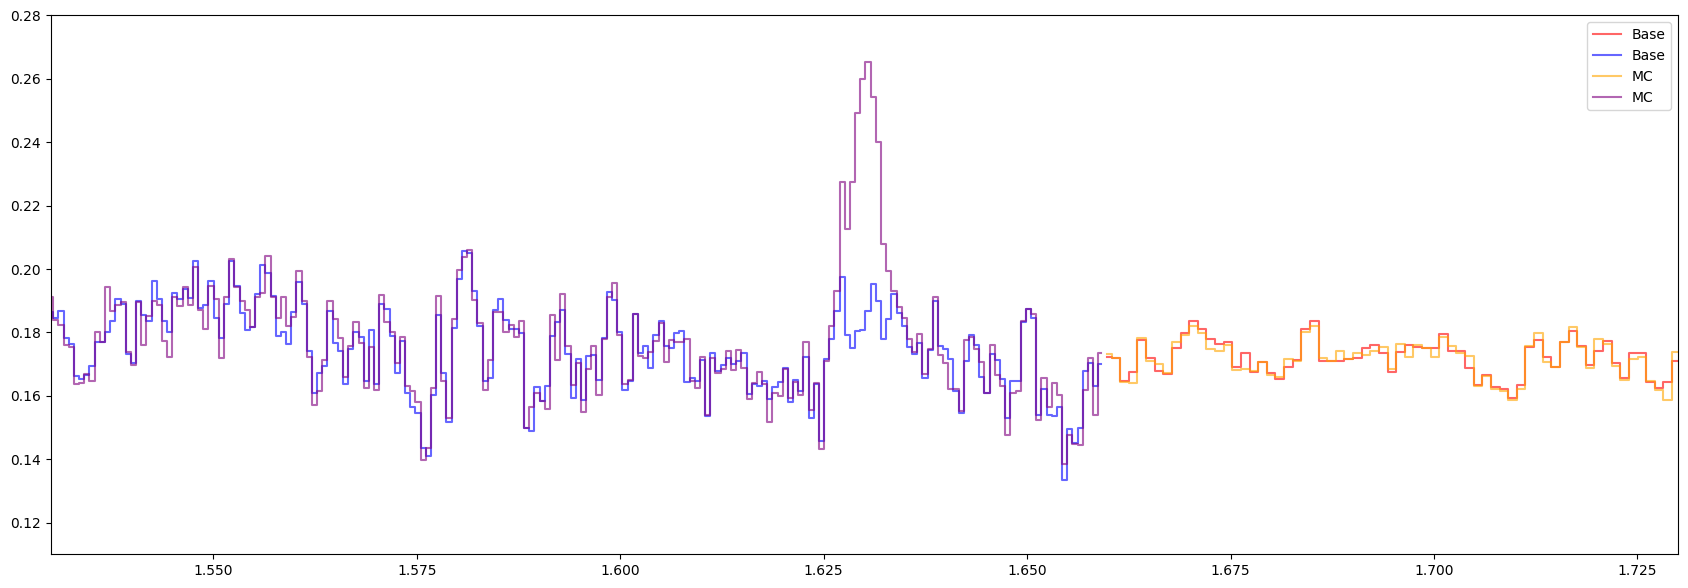

In [8]:
decayrate = 4e-4
lam0 = 1.63

new_specset = base_specset.add_DM_line(decayrate, lam0).resample_flux()

fig, ax = plt.subplots(figsize=(21, 7))
base_specset.plot(ax=ax, error_band=0, 
             distinct_plot_args=[{"color": "red"},
                                 {"color": "blue"}],
             alpha=0.6, label="Base")
new_specset.plot(ax=ax, error_band=0,
             distinct_plot_args=[{"color": "orange"},
                                 {"color": "purple"}],
             alpha=0.6, label="MC")
ax.set_xlim(lam0 - 0.1, lam0 + 0.1)
ax.set_ylim(0.11, 0.28)
ax.legend()

In [9]:
keys_for_linesearch = {
    "analysis":[
      "width_factor", 
      "padding", 
      "num_knots", 
      "chisq_step", 
      "limit_guess", 
      "max_clip_iters", 
      "clipping_factor", 
      "Ntrials", 
      "Nbins", 
      "power_threshold"],
    "halo":[ 
      "sigma_v"]}
linesearch_configs = {k:prev_configs[k1][k] 
                       for k1, l1 in keys_for_linesearch.items()
                       for k in l1
                       if k in prev_configs[k1].keys()} 

print("linsearch configs used in v1:")
for k, v in linesearch_configs.items():
    print(f"    {k} = {v}")
print()
default_setup = dmd.linesearch.LineSearchSetup(**linesearch_configs)

linesearch_configs["num_knots"] = 6
linesearch_configs["width_factor"] = 20
narrow_setup = dmd.linesearch.LineSearchSetup(**linesearch_configs)

setups = {"default":default_setup, "narrow":narrow_setup}
print("running below with:")
for n, d in setups.items():
    print(f"    {n}:")
    for k, v in d.__dict__.items():
        print(f"        {k} = {v}")

linsearch configs used in v1:
    width_factor = 150.0
    padding = 1e-08
    num_knots = 5
    chisq_step = 4.0
    limit_guess = [1e-05, 0.001]
    max_clip_iters = 100
    clipping_factor = 3.0
    Ntrials = 1000
    Nbins = 15
    power_threshold = 0.1587
    sigma_v = 0.0005337025523170433

running below with:
    default:
        width_factor = 150.0
        padding = 1e-08
        num_knots = 5
        chisq_step = 4.0
        limit_guess = [1e-05, 0.001]
        max_clip_iters = 100
        clipping_factor = 3.0
        Ntrials = 1000
        Nbins = 15
        power_threshold = 0.1587
        sigma_v = 0.0005337025523170433
    narrow:
        width_factor = 20
        padding = 1e-08
        num_knots = 6
        chisq_step = 4.0
        limit_guess = [1e-05, 0.001]
        max_clip_iters = 100
        clipping_factor = 3.0
        Ntrials = 1000
        Nbins = 15
        power_threshold = 0.1587
        sigma_v = 0.0005337025523170433


fit 1e-05 line at 1.45

example fit using default:
  Chisq/dof: 9.750152918521696
372
[[       nan        nan]
 [1.32976262 1.57023738]]
[[0.20019132 0.19391053 0.1807819  0.18087378 0.18133461]]
0
[0.00235407 0.00140402]

example fit using narrow:
  Chisq/dof: 4.699499079352825
44
[[       nan        nan]
 [1.43396835 1.46603165]]
[[0.19385141 0.18021069 0.17927859 0.17851623 0.1811927  0.16582048]]
0
[0.00235407 0.00140402]



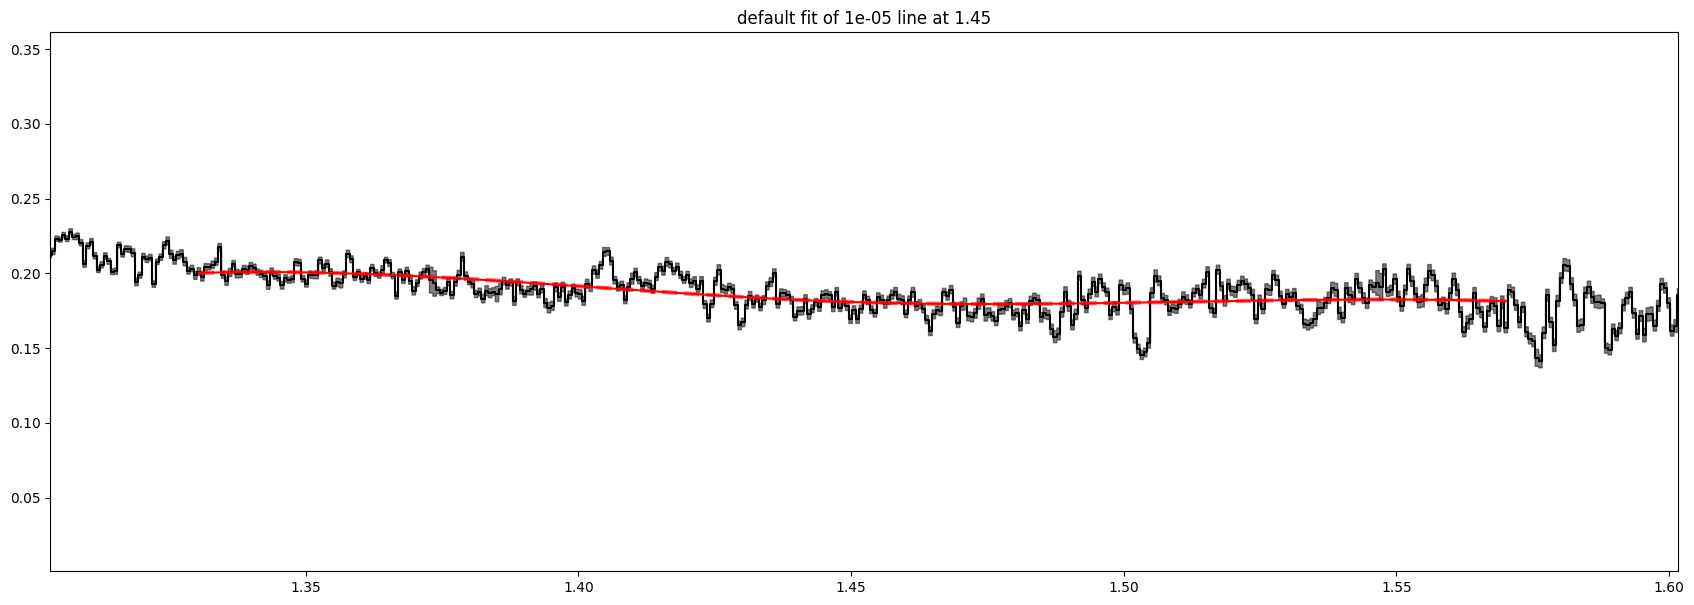

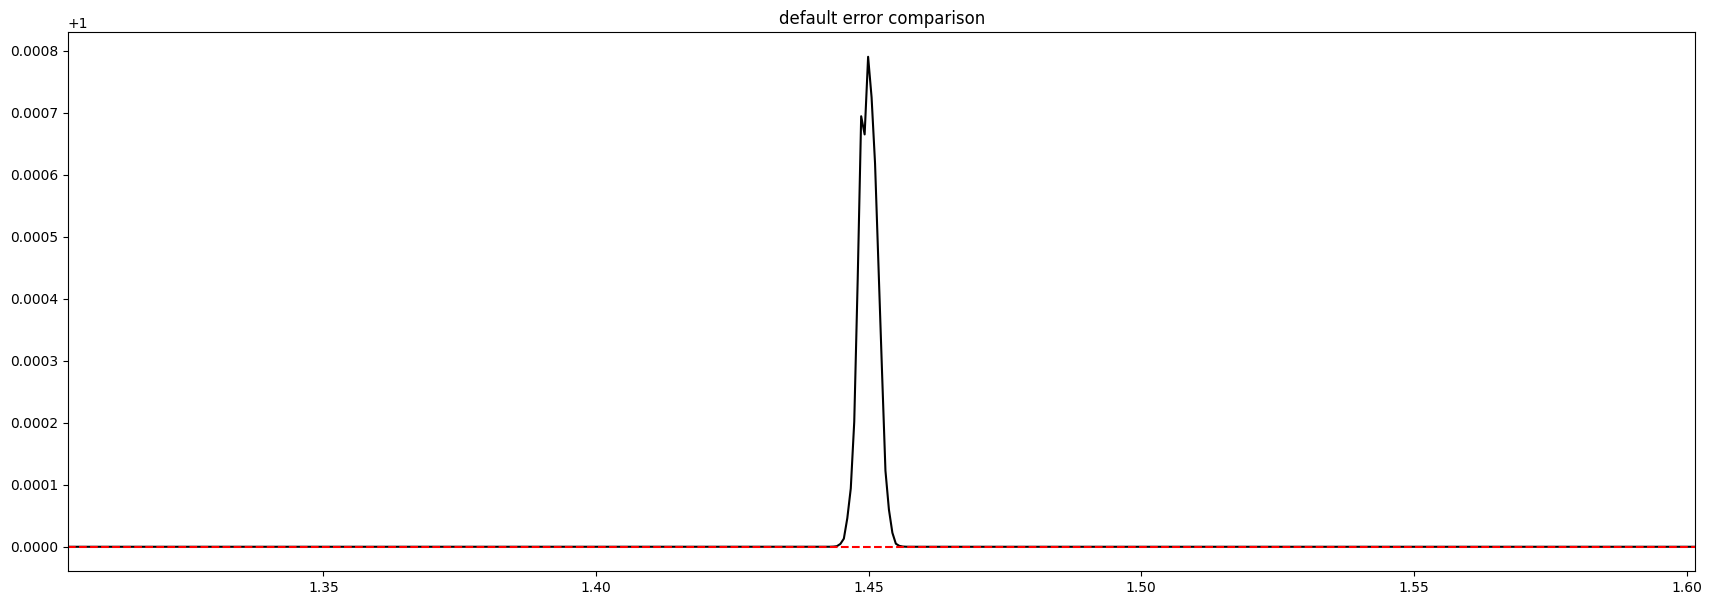

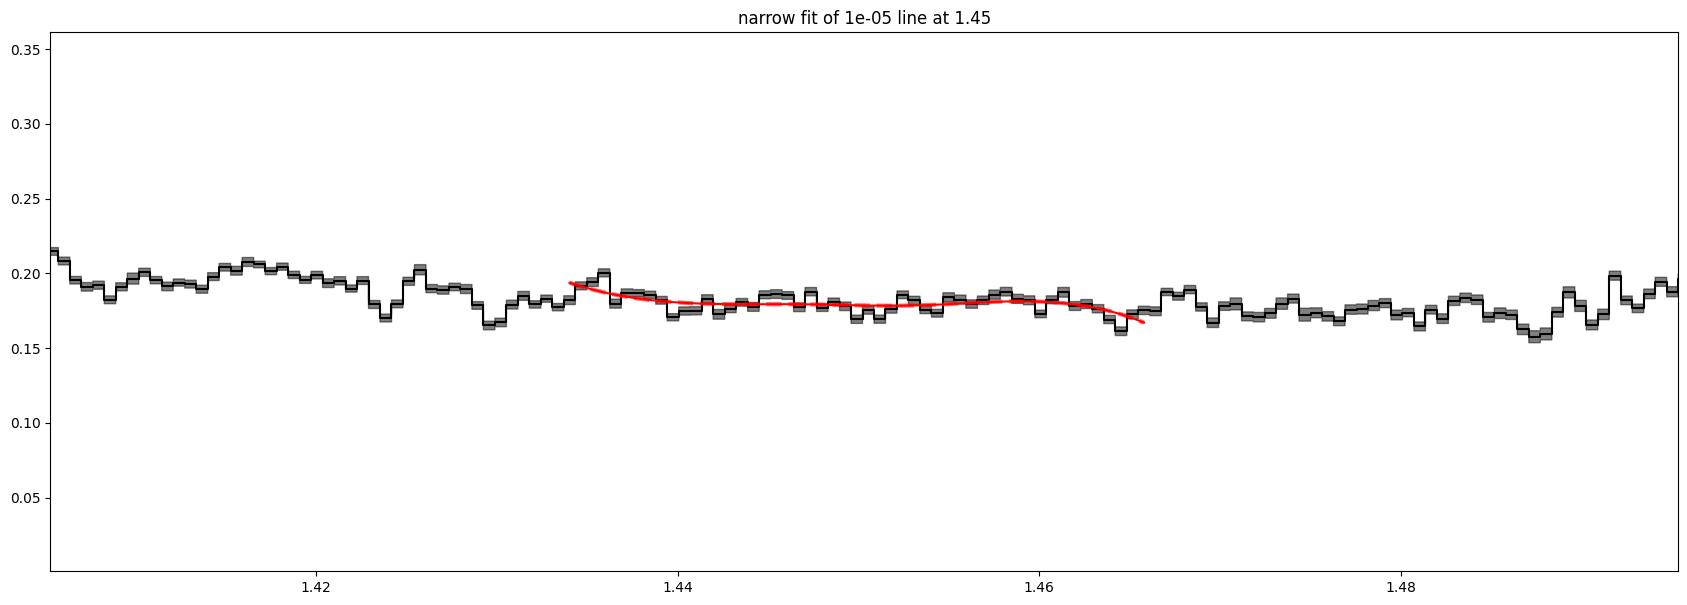

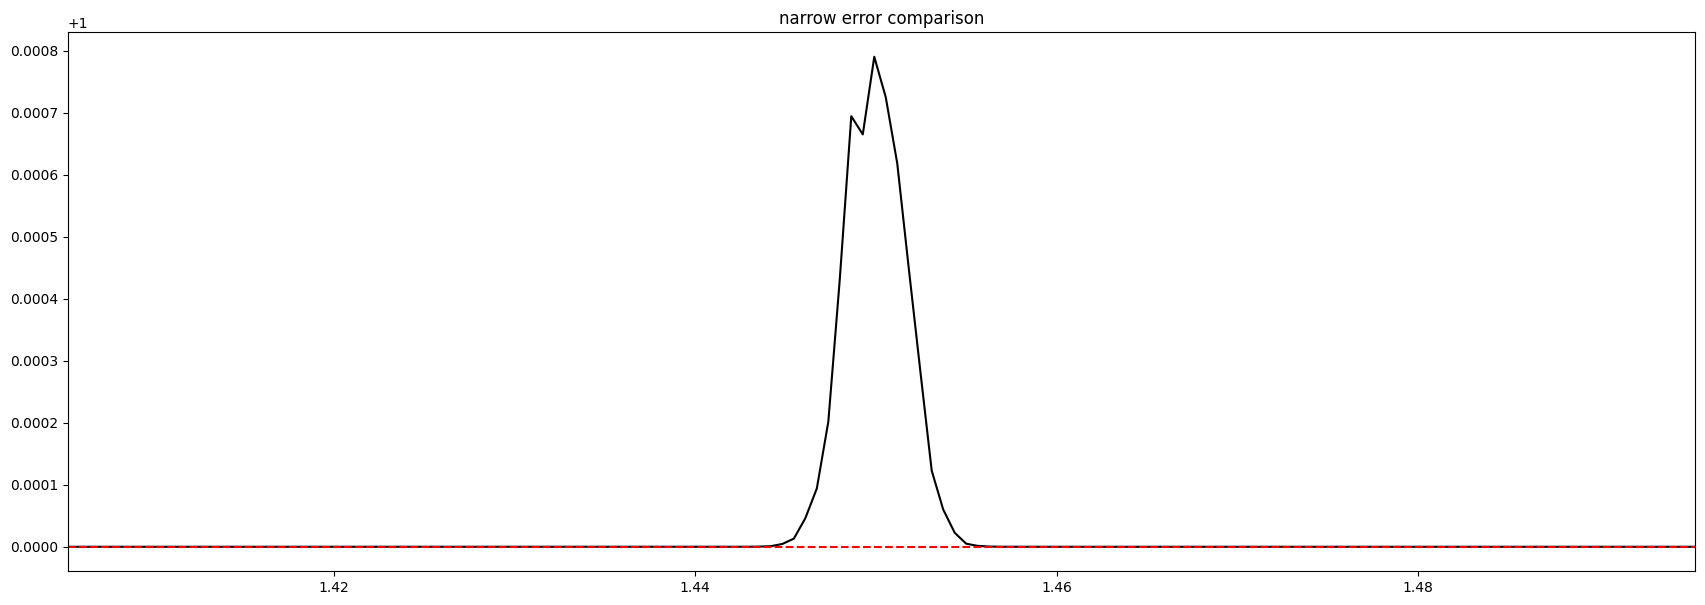

In [10]:
testing = np.array([[1.45, 2.1, 2.8], 
                    [1e-5, 1e-4, 1e-4]])
lam0, decayrate = testing[:, 0]
print(f"fit {decayrate} line at {lam0}\n")

for name, setup in setups.items():
    print(f"example fit using {name}:")
    new_specset = base_specset.add_DM_line(decayrate, lam0)\
                            #   .resample_flux()
    searcher = dmd.linesearch.LineSearcher(setup, new_specset, lam0)
    eg_knot_vals = searcher.fit_continuum_only()
    eg_decayrate = 0
    # eg_knot_vals, eg_decayrate = searcher.fit_continuum_plus_line()
    chisq_dof = \
        searcher.chisq(eg_knot_vals, eg_decayrate)/ \
        searcher.dof_continuum_plus_line
    print(f"  Chisq/dof: {chisq_dof}")
    print(searcher.dof_continuum_plus_line)
    print(f"{searcher.fit_intervals}")
    print(f"{eg_knot_vals}")
    print(f"{eg_decayrate}")
    print(searcher.data.inst_res)
    print()
    
    fig, ax = plt.subplots(figsize=(21, 7))
    new_specset.plot(ax=ax, error_band=0.5, color='black', alpha=1)
    model = searcher.spline_plus_line_model(eg_knot_vals, eg_decayrate, 
                                            searcher.lams_to_fit)
    model_continuum_only = searcher.spline_plus_line_model(eg_knot_vals, 0,
                                                        searcher.lams_to_fit)
    for i_model, i_specs in enumerate(searcher.to_fit):
        ax.plot(searcher.lams_to_fit[i_specs], model[i_model], color="red")
        ax.plot(searcher.lams_to_fit[i_specs], model_continuum_only[i_model], 
                color="red", alpha=0.6, linewidth=3, linestyle='dashed')
    ax.set_xlim(*searcher.get_plot_limits(margin=0.02))
    ax.set_title(F"{name} fit of {decayrate} line at {lam0}")

    fig, ax = plt.subplots(figsize=(21, 7))
    for i in range(new_specset.N_specs):
        ax.plot(base_specset.lam[i], 
                new_specset.error[i]/base_specset.error[i], color='black')
    ax.axhline(1, color='red', linestyle='dashed')
    ax.set_xlim(*searcher.get_plot_limits(margin=0.02))
    ax.set_title(F"{name} error comparison")


-2.083985515842931e-05


Text(0.5, 1.0, 'narrow fit of 1e-05 line at 1.45')

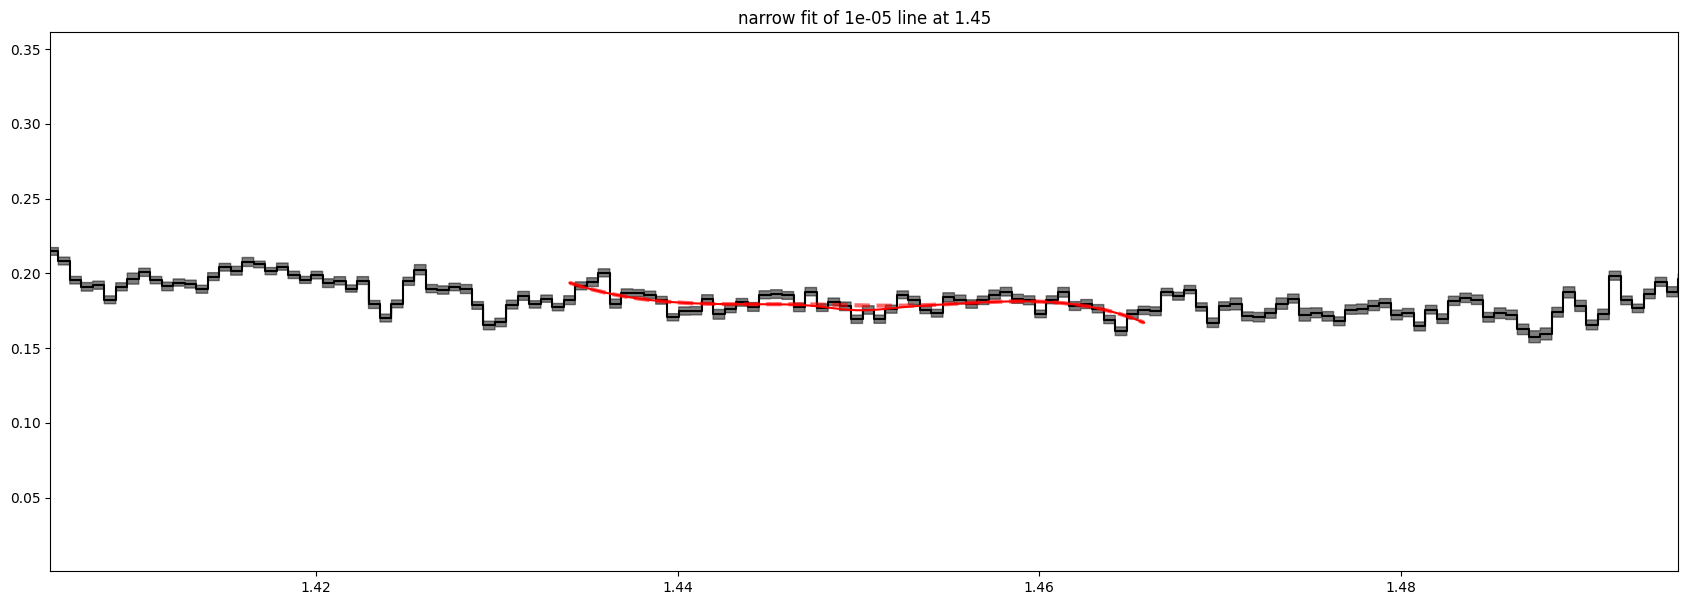

In [11]:
eg_decayrate = searcher.fit_line_only(eg_knot_vals)
print(eg_decayrate)

fig, ax = plt.subplots(figsize=(21, 7))
new_specset.plot(ax=ax, error_band=0.5, color='black', alpha=1)
model = searcher.spline_plus_line_model(eg_knot_vals, eg_decayrate, 
                                        searcher.lams_to_fit)
model_continuum_only = searcher.spline_plus_line_model(eg_knot_vals, 0,
                                                    searcher.lams_to_fit)
for i_model, i_specs in enumerate(searcher.to_fit):
    ax.plot(searcher.lams_to_fit[i_specs], model[i_model], color="red")
    ax.plot(searcher.lams_to_fit[i_specs], model_continuum_only[i_model], 
            color="red", alpha=0.6, linewidth=3, linestyle='dashed')
ax.set_xlim(*searcher.get_plot_limits(margin=0.02))
ax.set_title(F"{name} fit of {decayrate} line at {lam0}")

1.058052070725578e-17
4.699499079352976


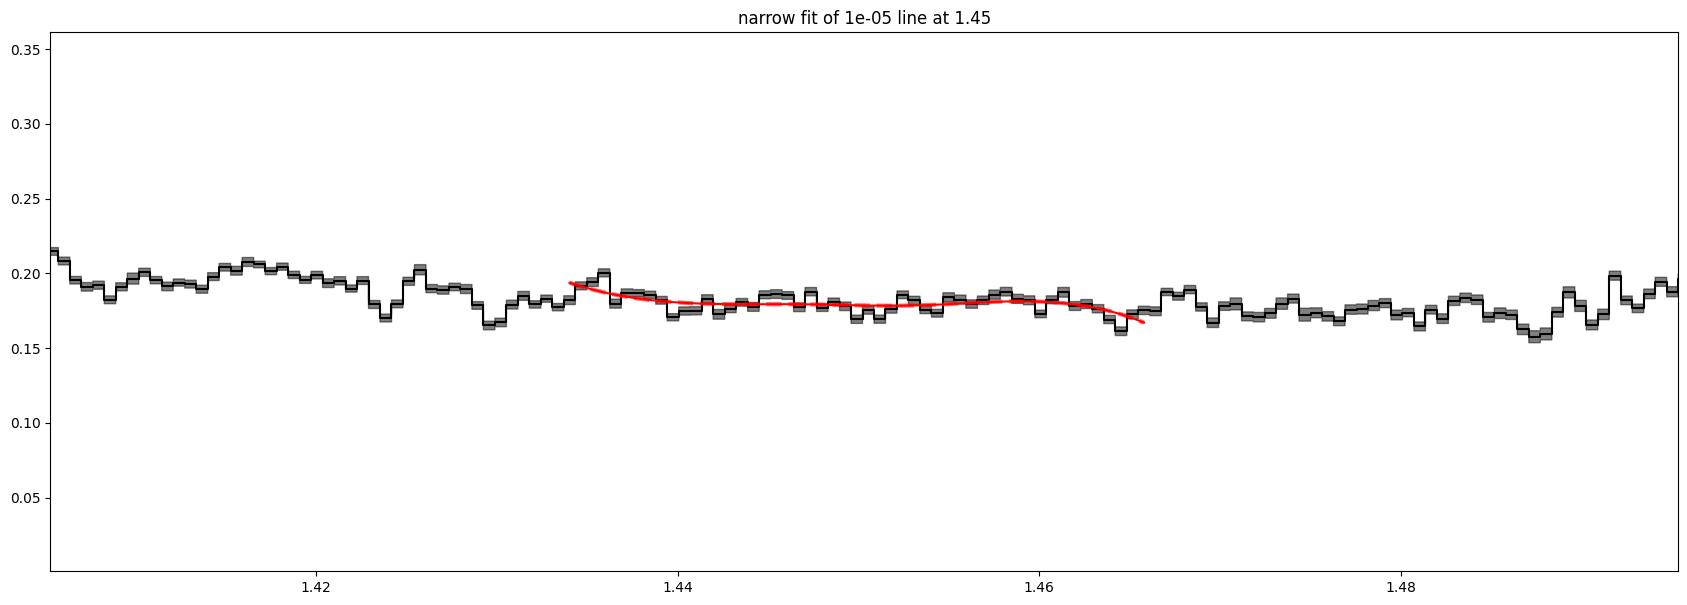

In [12]:
eg_knot_vals, eg_decayrate = searcher.fit_continuum_plus_line()
print(eg_decayrate)

fig, ax = plt.subplots(figsize=(21, 7))
new_specset.plot(ax=ax, error_band=0.5, color='black', alpha=1)
model = searcher.spline_plus_line_model(eg_knot_vals, eg_decayrate, 
                                        searcher.lams_to_fit)
model_continuum_only = searcher.spline_plus_line_model(eg_knot_vals, 0,
                                                    searcher.lams_to_fit)
for i_model, i_specs in enumerate(searcher.to_fit):
    ax.plot(searcher.lams_to_fit[i_specs], model[i_model], color="red")
    ax.plot(searcher.lams_to_fit[i_specs], model_continuum_only[i_model], 
            color="red", alpha=0.6, linewidth=3, linestyle='dashed')
ax.set_xlim(*searcher.get_plot_limits(margin=0.02))
ax.set_title(F"{name} fit of {decayrate} line at {lam0}")

chisq_dof = \
    searcher.chisq(eg_knot_vals, eg_decayrate)/ \
    searcher.dof_continuum_plus_line
print(chisq_dof)

In [13]:
print(searcher.bf_decay_rate)
print(searcher.bf_knot_vals)
print(searcher.decayrate_ci_from_chisq(4))

new_searcher = dmd.linesearch.LineSearcher(
    narrow_setup, 
    searcher.data.rescale_error(chisq_dof), 
    lam0)
print(new_searcher.decayrate_ci_from_chisq(4))

1.058052070725578e-17
[[0.19385141 0.18021069 0.17927859 0.17851623 0.1811927  0.16582048]]
[0.00000000e+00 5.60700235e-06]
[0.00000000e+00 5.84691678e-05]


In [14]:
n_trials = 10**3
chisq_step = 4
error_scales = np.array([1, np.sqrt(chisq_dof)])
bf_decayrates_dict = {
    setup_name:np.full((n_trials, error_scales.size), np.nan)
    for setup_name in setups.keys()}
ci_dict = {
    setup_name:np.full((error_scales.size, 2), np.nan)
    for setup_name in setups.keys()}
for setup_name, setup in setups.items():
    for i, scale_factor in enumerate(error_scales):
        trial_specset = base_specset.add_DM_line(decayrate, lam0)\
                                    .rescale_error(scale_factor)
        search = dmd.linesearch.LineSearcher(setup, trial_specset, lam0)
        ci_dict[setup_name][i] = search.decayrate_ci_from_chisq(chisq_step) 
        for j in tqdm(range(n_trials)):
            trial_search = dmd.linesearch.LineSearcher(
                setup, trial_specset.resample_flux(), lam0)
            _, bf_decayrate = trial_search.fit_continuum_plus_line()
            bf_decayrates_dict[setup_name][j, i] = bf_decayrate

100%|██████████| 1000/1000 [01:14<00:00, 13.37it/s]


In [15]:
print(f"input decayrate: {decayrate:.2e}\n")

med = {setup_name:np.median(bf_decayrates, axis=0)
       for setup_name, bf_decayrates in bf_decayrates_dict.items()}
sigma = {setup_name:(ci_dict[setup_name][1, :] - ci_dict[setup_name][0, :])/2
         for setup_name in med.keys()}
diff_width = {
    setup_name:np.abs(med[setup_name] - decayrate)/sigma[setup_name]
    for setup_name in med.keys()}

input decayrate: 1.00e-05



/tmp/ipykernel_25706/1200251388.py:8: RuntimeWarning: divide by zero encountered in divide
  setup_name:np.abs(med[setup_name] - decayrate)/sigma[setup_name]


In [18]:
for setup_name in bf_decayrates_dict:
    print(F"{setup_name} results:")
    for i, scale_factor in enumerate(error_scales):
        print(f"  with error scaling {scale_factor:.2f}:\n"
            f"      output decayrate: "
            f"{ci_dict[setup_name][i][0]:.2e}  "
            f"{med[setup_name][i]:.2e}  " 
            f"{ci_dict[setup_name][i][1]:.2e}\n")
    print()

default results:
  with error scaling 1.00:
      output decayrate: 0.00e+00  5.66e-20  3.17e-06

  with error scaling 2.17:
      output decayrate: 0.00e+00  5.64e-20  1.33e-05


narrow results:
  with error scaling 1.00:
      output decayrate: 0.00e+00  8.39e-21  5.61e-06

  with error scaling 2.17:
      output decayrate: 0.00e+00  1.18e-21  2.02e-05




default, scale 1.00,
  frac inside ci: 100.00%

default, scale 2.17,
  frac inside ci: 100.00%

narrow, scale 1.00,
  frac inside ci: 100.00%

narrow, scale 2.17,
  frac inside ci: 99.30%



Text(0.5, 0.98, 'injection recovery: 1.00e-05 line at 1.45')

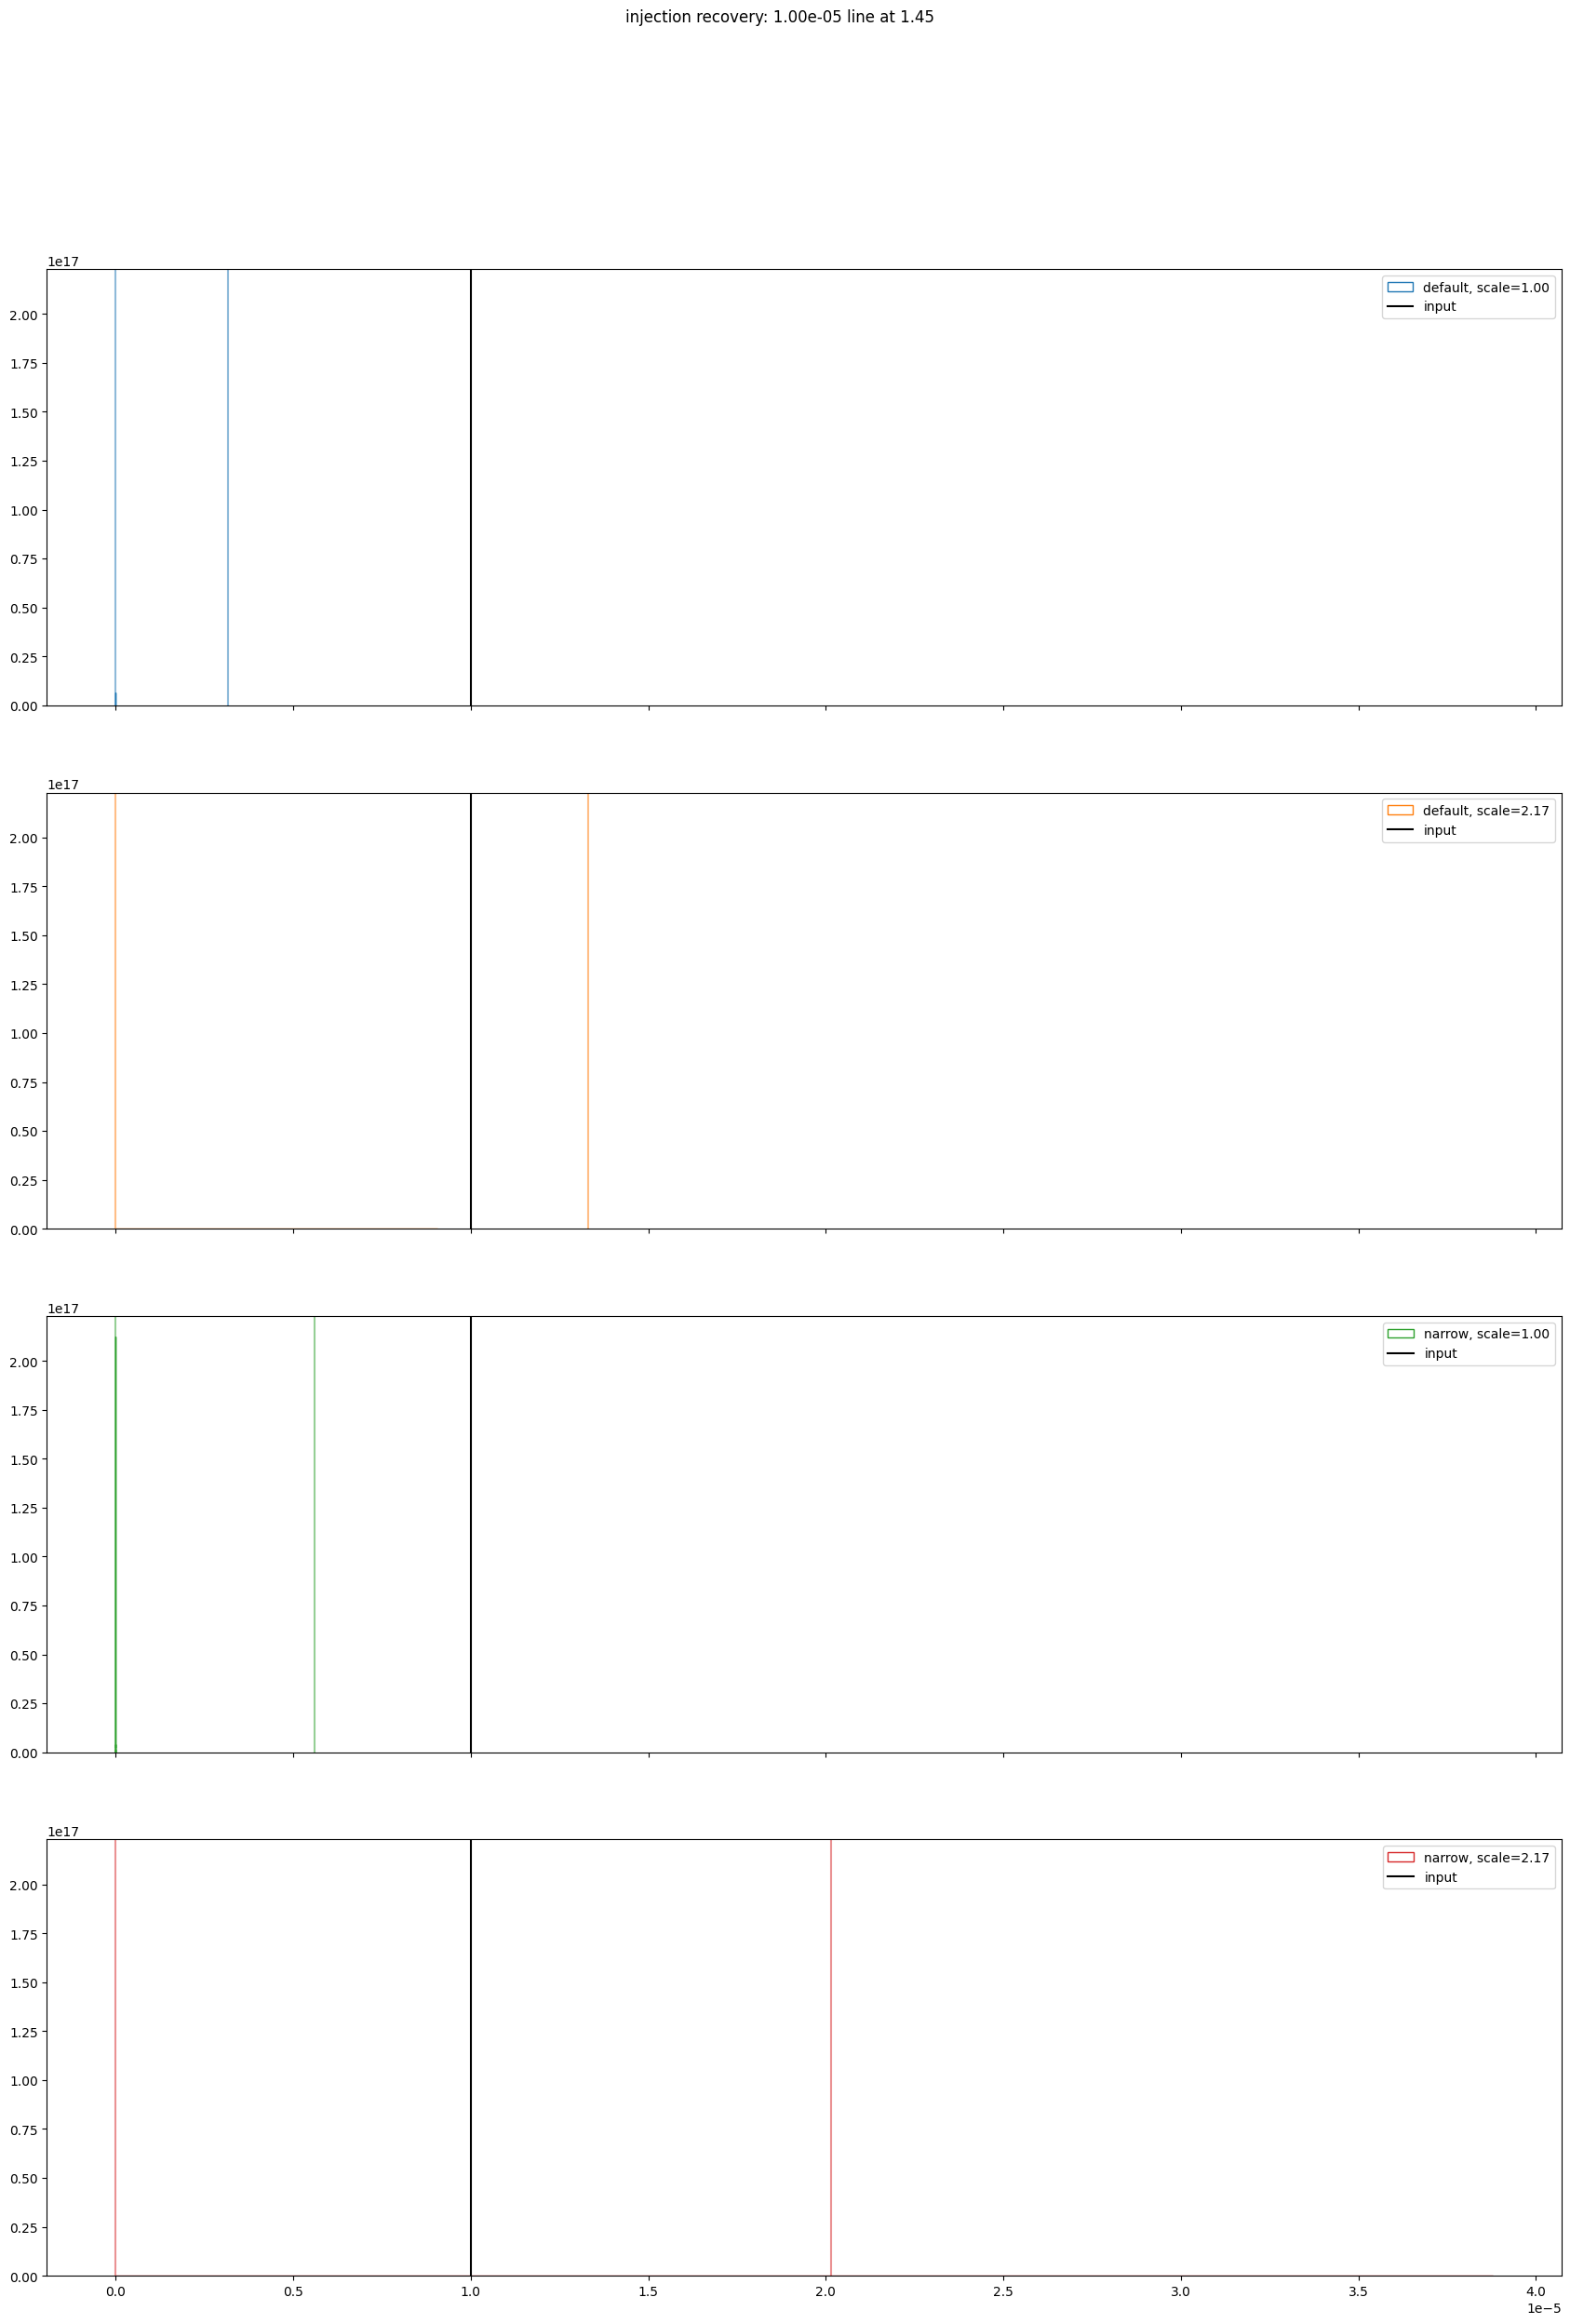

In [20]:
fig, axes = plt.subplots(len(setups)*error_scales.size,
                         sharex=True, sharey=True, 
                         figsize=(21, 4*7))
cmap = plt.get_cmap("tab10")
k = 0
for setup_name, bf_decayrates in bf_decayrates_dict.items():
    for i, scale_factor in enumerate(error_scales):
        axes[k].hist(bf_decayrates[:, i], bins=20, density=True, 
                     color=cmap(k), histtype='step', align='mid',
                     label=f"{setup_name}, scale={scale_factor:0.2f}")
        [axes[k].axvline(v, color=cmap(k), alpha=0.5) 
         for v in ci_dict[setup_name][i]]
        axes[k].axvline(decayrate, color='black', 
                        linestyle='solid', label="input")
        ax.ticklabel_format(axis="x", style="sci", scilimits=(0, 0))
        ax.ticklabel_format(axis="y", style="plain")
        inside = ((ci_dict[setup_name][i][0] < bf_decayrates[:, i]) &
                  (bf_decayrates[:, i] < ci_dict[setup_name][i][1]))
        frac = np.sum(inside)/bf_decayrates.shape[0]
        print(f"{setup_name}, scale {scale_factor:.2f},\n"
              f"  frac inside ci: {100*frac:.2f}%\n")
        axes[k].legend()
        k += 1
fig.suptitle(f"injection recovery: {decayrate:.2e} line at {lam0}")

# Depdence on input g

In [34]:
decayrate_lims = 1e-6, 5e-3
lam0 = 2.1 #1.45
steps = 20
n_trials = 5*10**2

searcher = dmd.linesearch.LineSearcher(narrow_setup, new_specset, lam0)
eg_knot_vals = searcher.fit_continuum()
chisq_dof = searcher.chisq(eg_knot_vals, 0)/searcher.dof_continuum_only

decayrates = np.geomspace(*decayrate_lims, steps)
output = np.full(steps, np.nan)
std_output = np.full(steps, np.nan)
for i, dr in tqdm(enumerate(decayrates), total=steps):
     hold = np.full(n_trials, np.nan)
     for j in range(n_trials):
          trial_specset = base_specset.add_DM_line(dr, lam0)\
                                   .rescale_error(np.sqrt(chisq_dof))\
                                   .resample_flux()
          searcher = dmd.linesearch.LineSearcher(narrow_setup, trial_specset, lam0)
          _, hold[j] = searcher.fit_continuum_plus_line()
     quants = np.quantile(hold, [0.025, 0.5, 0.975])
     output[i] = quants[1]
     std_output[i] = (quants[2] - quants[0])/2
          

  0%|          | 0/20 [00:00<?, ?it/s]

100%|██████████| 20/20 [14:34<00:00, 43.72s/it]


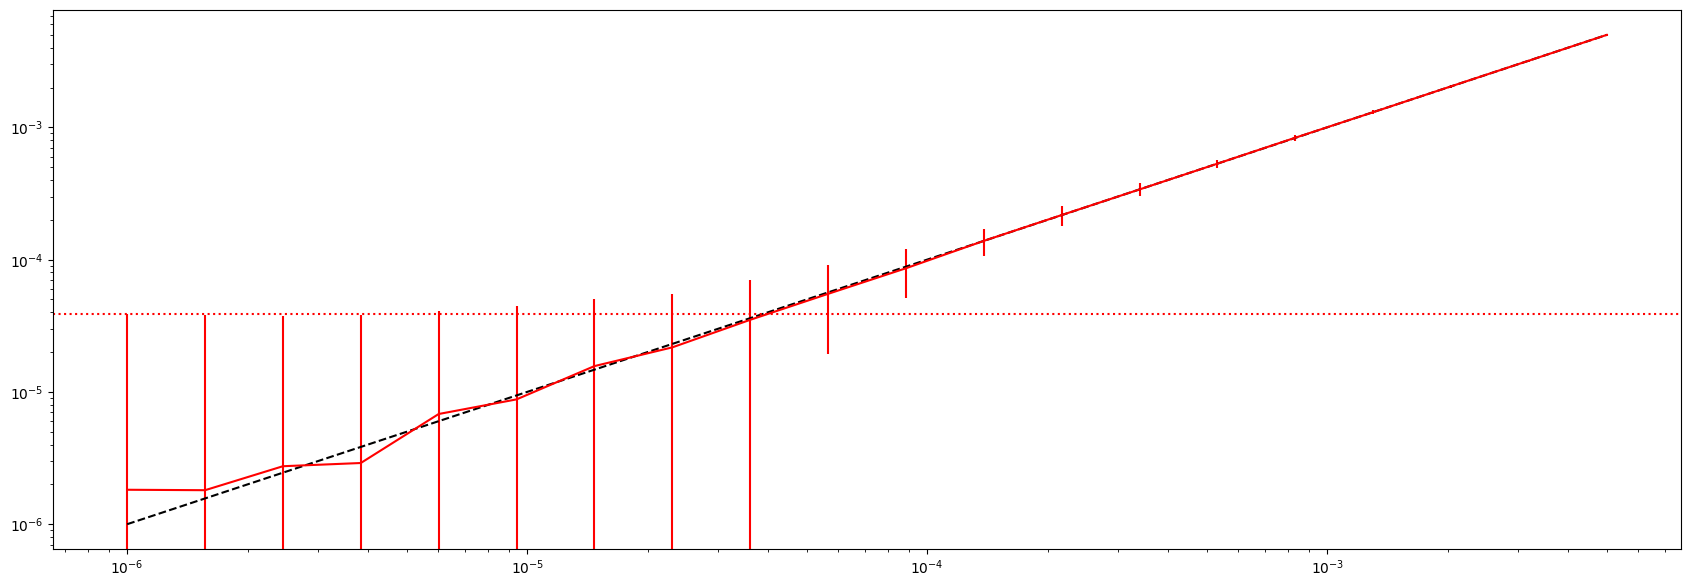

In [35]:
fig, ax = plt.subplots(figsize=(21, 7))
ax.errorbar(decayrates, output, yerr=std_output, color='red')
ax.plot(decayrates, decayrates, linestyle='dashed', color='black')
ax.set_xscale('log')
ax.set_yscale('log')

ax.axhline(output[0] + std_output[0], color='red', linestyle='dotted')